# DL_02 - Clasificador IDH: MedicalNet ResNet-18 (Adaptado)

**CAMBIOS RESPECTO AL ORIGINAL:**
- Usa `labels_idh_corregido.csv` (sin los 7 casos NOS/NEC)
- Usa el MISMO hold-out que ML (`clasificador_v2/results/holdout_ids.csv`)
- Nombres correctos de archivos stripped
- Guarda en `dl_clasificador_v2/medicalnet/` (no sobreescribe originales)

In [ ]:
# CELDA 1 - Instalacion
!pip install monai[all] nibabel torch torchvision scikit-learn matplotlib seaborn huggingface_hub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5

In [ ]:
# CELDA 2 - Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELDA 3 - Importar librerias y configurar rutas
import json
import shutil
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from monai.networks.nets import resnet18
from huggingface_hub import hf_hub_download
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix, roc_curve,
    matthews_corrcoef, recall_score, accuracy_score,
)

warnings.filterwarnings('ignore')

# --- Rutas principales ---
BASE       = Path('/content/drive/MyDrive/GBM_TESIS')
SS_DIR     = BASE / 'SS_PIPELINE'
STRIPPED   = SS_DIR / 'stripped_images'
PRED_DIR   = SS_DIR / 'predictions'

# CAMBIO: carpeta v2 para no sobreescribir originales
DL_DIR     = SS_DIR / 'dl_clasificador_v2'
MN_DIR     = BASE / 'medicalnet_weights'
MN_WEIGHTS = MN_DIR / 'resnet18.pth'
OUT_DIR    = DL_DIR / 'medicalnet'

for d in [MN_DIR, OUT_DIR,
          OUT_DIR / 'models',
          OUT_DIR / 'figures',
          OUT_DIR / 'results']:
    d.mkdir(parents=True, exist_ok=True)

# --- Configuracion del entrenamiento ---
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CROP_SIZE  = (64, 64, 64)
BATCH_SIZE = 8
N_EPOCHS   = 100
LR         = 1e-3
DROPOUT    = 0.5
THRESHOLD  = 0.5
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)

print(f'Dispositivo : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'\nVerificando rutas:')
print(f'  STRIPPED       : {"✅" if STRIPPED.exists() else "❌"}')
print(f'  PRED_DIR       : {"✅" if PRED_DIR.exists() else "❌"}')
print(f'  Labels         : {"✅" if (BASE / "Dataset/labels_idh_corregido.csv").exists() else "❌"}')
print(f'  Hold-out ML v2 : {"✅" if (SS_DIR / "clasificador_v2/results/holdout_ids.csv").exists() else "❌"}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Dispositivo : cuda
GPU         : NVIDIA A100-SXM4-40GB
VRAM        : 42.4 GB

Verificando rutas:
  STRIPPED       : ✅
  PRED_DIR       : ✅
  Labels         : ✅
  Hold-out ML v2 : ✅


In [ ]:
# CELDA 4 - Descargar pesos MedicalNet desde HuggingFace
MN_DIR.mkdir(exist_ok=True)

if not MN_WEIGHTS.exists():
    print('Descargando pesos MedicalNet ResNet-18...')
    path = hf_hub_download(
        repo_id='TencentMedicalNet/MedicalNet-Resnet18',
        filename='resnet_18.pth',
        local_dir=str(MN_DIR),
    )
    shutil.copy2(path, str(MN_WEIGHTS))
    print(f'Guardados en: {MN_WEIGHTS}')
else:
    print(f'Pesos ya disponibles: {MN_WEIGHTS}')

Pesos ya disponibles: /content/drive/MyDrive/GBM_TESIS/medicalnet_weights/resnet18.pth


In [ ]:
# CELDA 5 - Construir dataset y usar mismo hold-out que ML
# CAMBIO: usa labels_idh_corregido.csv y mismo hold-out que ML

labels_path = BASE / 'Dataset/labels_idh_corregido.csv'
df_labels   = pd.read_csv(str(labels_path), sep=';')
df_labels.columns = df_labels.columns.str.strip()

print(f'Labels cargados: {len(df_labels)} casos')
print(df_labels['idh_status'].value_counts())

# Construir rutas con nombres correctos de archivos
registros    = []
sin_archivos = []
for _, row in df_labels.iterrows():
    sid   = row['caso']
    label = 1 if row['idh_status'] == 'mutado' else 0
    strip_dir = STRIPPED / sid

    t1    = strip_dir / f'{sid}_T1_stripped.nii.gz'
    t1ce  = strip_dir / f'{sid}_T1GD_stripped.nii.gz'
    t2    = strip_dir / f'{sid}_T2_stripped.nii.gz'
    flair = strip_dir / f'{sid}_FLAIR_stripped.nii.gz'
    mask  = PRED_DIR  / sid / f'{sid}__seg.nii.gz'

    if all(f.exists() for f in [t1, t1ce, t2, flair, mask]):
        registros.append({
            'sid'      : sid,
            'IDH'      : label,
            't1'       : str(t1),
            't1ce'     : str(t1ce),
            't2'       : str(t2),
            'flair'    : str(flair),
            'mask_path': str(mask),
        })
    else:
        sin_archivos.append(sid)

df_all = pd.DataFrame(registros)
print(f'\nCasos disponibles : {len(df_all)}')
print(f'  Wildtype        : {(df_all["IDH"]==0).sum()}')
print(f'  Mutado          : {(df_all["IDH"]==1).sum()}')
print(f'Sin archivos      : {len(sin_archivos)}')

# Usar mismo hold-out que ML
holdout_ml_path = SS_DIR / 'clasificador_v2/results/holdout_ids.csv'
df_holdout_ml   = pd.read_csv(str(holdout_ml_path))
ids_holdout_ml  = df_holdout_ml['subject_id'].tolist()

df_hold = df_all[df_all['sid'].isin(ids_holdout_ml)].copy()
df_dev  = df_all[~df_all['sid'].isin(ids_holdout_ml)].copy()

df_train, df_val = train_test_split(
    df_dev, test_size=0.20,
    stratify=df_dev['IDH'],
    random_state=RANDOM_STATE)

print(f'\nDistribucion:')
print(f'  Train  : {len(df_train)} ({(df_train["IDH"]==1).sum()} mut, {(df_train["IDH"]==0).sum()} wt)')
print(f'  Val    : {len(df_val)} ({(df_val["IDH"]==1).sum()} mut, {(df_val["IDH"]==0).sum()} wt)')
print(f'  Holdout: {len(df_hold)} ({(df_hold["IDH"]==1).sum()} mut, {(df_hold["IDH"]==0).sum()} wt)')

df_train.to_csv(str(DL_DIR / 'dl_train_ids.csv'), index=False)
df_val.to_csv(str(DL_DIR / 'dl_val_ids.csv'), index=False)
df_hold.to_csv(str(DL_DIR / 'dl_holdout_ids.csv'), index=False)
print('Splits guardados.')

Labels cargados: 527 casos
idh_status
wildtype    458
mutado       69
Name: count, dtype: int64

Casos disponibles : 527
  Wildtype        : 458
  Mutado          : 69
Sin archivos      : 0

Distribucion:
  Train  : 336 (44 mut, 292 wt)
  Val    : 85 (11 mut, 74 wt)
  Holdout: 106 (14 mut, 92 wt)
Splits guardados.


In [ ]:
# CELDA 6 - Preprocesamiento
import numpy as np

def normalizar_volumen(vol):
    nonzero = vol[vol > 0]
    if len(nonzero) == 0:
        return vol
    return (vol - nonzero.mean()) / (nonzero.std() + 1e-8)


def crop_centrado_en_tumor(imagen, mascara):
    coords = np.where(mascara > 0)
    if len(coords[0]) > 0:
        centro = [int(np.mean(c)) for c in coords]
    else:
        centro = [s // 2 for s in imagen.shape[:3]]
    slices = []
    for i, (c, s) in enumerate(zip(centro, imagen.shape[:3])):
        half  = CROP_SIZE[i] // 2
        start = max(0, c - half)
        end   = min(s, start + CROP_SIZE[i])
        start = max(0, end - CROP_SIZE[i])
        slices.append(slice(start, end))
    crop      = imagen[slices[0], slices[1], slices[2]]
    pad_width = [(0, max(0, CROP_SIZE[i] - crop.shape[i])) for i in range(3)]
    return np.pad(crop, pad_width, mode='constant', constant_values=0)


def aumentar_volumen(vol, agresivo=True):
    tiene_canales = vol.ndim == 4
    target = CROP_SIZE[0]
    for eje in range(3):
        if np.random.rand() < 0.5:
            vol = np.flip(vol, axis=eje).copy()
    if agresivo and np.random.rand() < 0.5:
        k   = np.random.randint(1, 4)
        vol = np.rot90(vol, k=k, axes=(0, 1)).copy()
    prob_ruido = 0.3 if agresivo else 0.2
    std_ruido  = 0.1 if agresivo else 0.05
    if np.random.rand() < prob_ruido:
        vol = vol + np.random.normal(0, std_ruido, vol.shape).astype(np.float32)
    if agresivo and np.random.rand() < 0.3:
        from scipy.ndimage import zoom as scipy_zoom
        factor = np.random.uniform(0.85, 1.15)
        if tiene_canales:
            vol_z = scipy_zoom(vol, (factor, factor, factor, 1), order=1)
        else:
            vol_z = scipy_zoom(vol, factor, order=1)
        for ax in range(3):
            if vol_z.shape[ax] > target:
                start   = (vol_z.shape[ax] - target) // 2
                indices = [slice(None)] * vol_z.ndim
                indices[ax] = slice(start, start + target)
                vol_z   = vol_z[tuple(indices)]
            elif vol_z.shape[ax] < target:
                pad_total  = target - vol_z.shape[ax]
                pad_before = pad_total // 2
                pad_after  = pad_total - pad_before
                pad_width  = [(0,0)] * vol_z.ndim
                pad_width[ax] = (pad_before, pad_after)
                vol_z = np.pad(vol_z, pad_width, mode='constant')
        vol = vol_z
    return vol.astype(np.float32)


print('Funciones de preprocesamiento definidas.')

Funciones de preprocesamiento definidas.


In [ ]:
# CELDA 7 - Dataset con 4 modalidades

class DatasetIDH(Dataset):
    def __init__(self, dataframe, aplicar_aumentacion=False):
        self.df                  = dataframe.reset_index(drop=True)
        self.aplicar_aumentacion = aplicar_aumentacion

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila    = self.df.iloc[idx]
        label   = int(fila['IDH'])
        mascara = nib.load(str(fila['mask_path'])).get_fdata().astype(np.uint8)

        vols = []
        for mod in ['t1', 't1ce', 't2', 'flair']:
            vol = nib.load(str(fila[mod])).get_fdata().astype(np.float32)
            vol = normalizar_volumen(vol)
            vol = crop_centrado_en_tumor(vol, mascara)
            vols.append(vol)
        volumen = np.stack(vols, axis=-1)  # (64, 64, 64, 4)

        if self.aplicar_aumentacion:
            volumen = aumentar_volumen(volumen, agresivo=(label == 1))

        imagen = torch.tensor(
            volumen if isinstance(volumen, np.ndarray) else np.array(volumen),
            dtype=torch.float32
        ).permute(3, 0, 1, 2)  # (4, 64, 64, 64)

        return imagen, torch.tensor(label, dtype=torch.float32)


dataset_train = DatasetIDH(df_train, aplicar_aumentacion=True)
dataset_val   = DatasetIDH(df_val,   aplicar_aumentacion=False)
dataset_hold  = DatasetIDH(df_hold,  aplicar_aumentacion=False)

labels_train = df_train['IDH'].tolist()
n_mut   = sum(labels_train)
n_wt    = len(labels_train) - n_mut
pesos   = [1.0/n_mut if l == 1 else 1.0/n_wt for l in labels_train]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(pesos),
    num_samples=len(pesos),
    replacement=True,
)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=0, pin_memory=False)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0, pin_memory=False)
loader_hold  = DataLoader(dataset_hold,  batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=0, pin_memory=False)

pos_weight = min(n_wt / n_mut, 3.0)
print(f'Train  : {len(dataset_train)} casos')
print(f'Val    : {len(dataset_val)} casos')
print(f'Holdout: {len(dataset_hold)} casos (mismo que ML)')
print(f'Batches por epoca : {len(loader_train)}')
print(f'pos_weight BCE    : {pos_weight:.2f}')

Train  : 336 casos
Val    : 85 casos
Holdout: 106 casos (mismo que ML)
Batches por epoca : 42
pos_weight BCE    : 3.00


In [ ]:
# CELDA 8 - Modelo MedicalNet ResNet-18 (4 canales)
backbone = resnet18(
    spatial_dims=3,
    n_input_channels=1,
    num_classes=2,
)

state = torch.load(str(MN_WEIGHTS), map_location='cpu')
if 'state_dict' in state:
    state = state['state_dict']
state = {k.replace('module.', ''): v for k, v in state.items()}
backbone.load_state_dict(state, strict=False)

pesos_originales = backbone.conv1.weight.data
pesos_nuevos     = pesos_originales.repeat(1, 4, 1, 1, 1) / 4.0
backbone.conv1   = nn.Conv3d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
backbone.conv1.weight.data = pesos_nuevos

for param in backbone.conv1.parameters():  param.requires_grad = True
for param in backbone.bn1.parameters():    param.requires_grad = False
for param in backbone.layer1.parameters(): param.requires_grad = False
for param in backbone.layer2.parameters(): param.requires_grad = False
for param in backbone.layer3.parameters(): param.requires_grad = True
for param in backbone.layer4.parameters(): param.requires_grad = True

encoder = nn.Sequential(
    backbone.conv1, backbone.bn1, backbone.act,
    backbone.maxpool,
    backbone.layer1, backbone.layer2,
    backbone.layer3, backbone.layer4,
)

model = nn.Sequential(
    encoder,
    nn.AdaptiveAvgPool3d(1),
    nn.Flatten(),
    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totales    : {n_total:,}')
print(f'Parametros entrenables: {n_trainable:,} ({100*n_trainable/n_total:.1f}%)')

Parametros totales    : 33,296,833
Parametros entrenables: 31,295,937 (94.0%)


In [ ]:
# CELDA 9 - Compilar el modelo
model.to(DEVICE)

criterio = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight]).to(DEVICE)
)
optimizador = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-3,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizador, T_max=N_EPOCHS, eta_min=1e-6
)

print('Modelo compilado.')
print(f'  Optimizador : Adam (LR=1e-4)')
print(f'  Loss        : BCEWithLogitsLoss (pos_weight={pos_weight:.2f})')
print(f'  Scheduler   : CosineAnnealingLR')

Modelo compilado.
  Optimizador : Adam (LR=1e-4)
  Loss        : BCEWithLogitsLoss (pos_weight=3.00)
  Scheduler   : CosineAnnealingLR


In [ ]:
# CELDA 10 - Entrenar el modelo
historial = {
    'train_loss': [], 'train_auc': [], 'train_acc': [],
    'val_loss':   [], 'val_auc':   [], 'val_acc':   [],
}
mejor_auc = 0.0

for epoca in range(1, N_EPOCHS + 1):

    # --- ENTRENAMIENTO ---
    model.train()
    loss_total, probs_train, labels_train = 0.0, [], []

    for imagenes, etiquetas in loader_train:
        imagenes  = imagenes.to(DEVICE)
        etiquetas = etiquetas.to(DEVICE).unsqueeze(1)
        optimizador.zero_grad()
        salida = model(imagenes)
        loss   = criterio(salida, etiquetas)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizador.step()
        loss_total += loss.item()
        probs_train.extend(torch.sigmoid(salida).detach().cpu().numpy().flatten())
        labels_train.extend(etiquetas.cpu().numpy().flatten())

    probs_train = np.array(probs_train)
    preds_train = (probs_train >= 0.5).astype(int)
    auc_train   = roc_auc_score(labels_train, probs_train) if len(set(labels_train)) > 1 else 0.0
    acc_train   = accuracy_score(labels_train, preds_train)
    loss_train  = loss_total / len(loader_train)

    # --- VALIDACION ---
    model.eval()
    loss_total, probs_val, labels_val = 0.0, [], []

    with torch.no_grad():
        for imagenes, etiquetas in loader_val:
            imagenes  = imagenes.to(DEVICE)
            etiquetas = etiquetas.to(DEVICE).unsqueeze(1)
            salida    = model(imagenes)
            loss_total += criterio(salida, etiquetas).item()
            probs_val.extend(torch.sigmoid(salida).cpu().numpy().flatten())
            labels_val.extend(etiquetas.cpu().numpy().flatten())

    probs_val = np.array(probs_val)
    preds_val = (probs_val >= 0.5).astype(int)
    auc_val   = roc_auc_score(labels_val, probs_val) if len(set(labels_val)) > 1 else 0.0
    acc_val   = accuracy_score(labels_val, preds_val)
    loss_val  = loss_total / len(loader_val)

    scheduler.step()

    historial['train_loss'].append(loss_train)
    historial['train_auc'].append(auc_train)
    historial['train_acc'].append(acc_train)
    historial['val_loss'].append(loss_val)
    historial['val_auc'].append(auc_val)
    historial['val_acc'].append(acc_val)

    if auc_val > mejor_auc:
        mejor_auc = auc_val
        torch.save(model.state_dict(), str(OUT_DIR / 'models/medicalnet_best.pth'))

    if epoca % 10 == 0 or epoca == 1:
        print(f'Epoca {epoca:3d}/{N_EPOCHS} | '
              f'Train Loss={loss_train:.4f} AUC={auc_train:.4f} Acc={acc_train:.4f} | '
              f'Val   Loss={loss_val:.4f} AUC={auc_val:.4f} Acc={acc_val:.4f}')

# Guardar historial para no perderlo si se reinicia la sesion
with open(str(OUT_DIR / 'results/training_history.json'), 'w') as f:
    json.dump(historial, f)

print(f'\nMejor Val AUC: {mejor_auc:.4f}')
print(f'Modelo guardado en: {OUT_DIR}/models/medicalnet_best.pth')

Epoca   1/100 | Train Loss=1.3015 AUC=0.5195 Acc=0.5179 | Val   Loss=0.9459 AUC=0.5860 Acc=0.1765
Epoca  10/100 | Train Loss=0.9187 AUC=0.8094 Acc=0.6369 | Val   Loss=0.9965 AUC=0.7690 Acc=0.4824
Epoca  20/100 | Train Loss=0.6488 AUC=0.9118 Acc=0.8125 | Val   Loss=0.4924 AUC=0.8980 Acc=0.9059
Epoca  30/100 | Train Loss=0.4771 AUC=0.9509 Acc=0.8929 | Val   Loss=0.5846 AUC=0.8882 Acc=0.8353
Epoca  40/100 | Train Loss=0.5320 AUC=0.9480 Acc=0.9167 | Val   Loss=0.5469 AUC=0.9165 Acc=0.8588
Epoca  50/100 | Train Loss=0.4470 AUC=0.9586 Acc=0.9137 | Val   Loss=0.5725 AUC=0.9226 Acc=0.8706
Epoca  60/100 | Train Loss=0.5338 AUC=0.9580 Acc=0.9196 | Val   Loss=0.8685 AUC=0.8636 Acc=0.8471
Epoca  70/100 | Train Loss=0.0602 AUC=0.9993 Acc=0.9881 | Val   Loss=0.8903 AUC=0.9275 Acc=0.9059
Epoca  80/100 | Train Loss=0.2127 AUC=0.9826 Acc=0.9821 | Val   Loss=0.9278 AUC=0.9005 Acc=0.8824
Epoca  90/100 | Train Loss=0.1534 AUC=0.9949 Acc=0.9762 | Val   Loss=1.0959 AUC=0.8919 Acc=0.8824
Epoca 100/100 | Trai

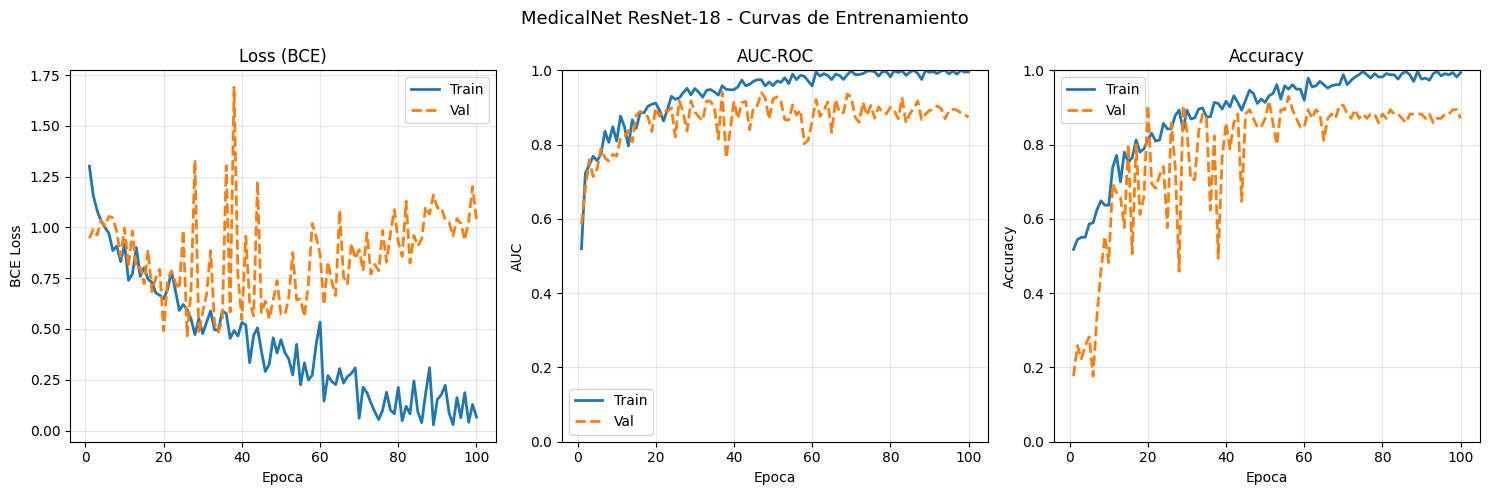

Graficas guardadas.


In [ ]:
# CELDA 11 - Graficas de entrenamiento
epocas      = range(1, len(historial['train_loss']) + 1)
color_train = '#1f77b4'  # azul
color_val   = '#ff7f0e'  # naranja

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(epocas, historial['train_loss'], label='Train', color=color_train, lw=2)
axes[0].plot(epocas, historial['val_loss'],   label='Val',   color=color_val,   lw=2, ls='--')
axes[0].set_title('Loss (BCE)')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epocas, historial['train_auc'], label='Train', color=color_train, lw=2)
axes[1].plot(epocas, historial['val_auc'],   label='Val',   color=color_val,   lw=2, ls='--')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epocas, historial['train_acc'], label='Train', color=color_train, lw=2)
axes[2].plot(epocas, historial['val_acc'],   label='Val',   color=color_val,   lw=2, ls='--')
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Epoca')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('MedicalNet ResNet-18 - Curvas de Entrenamiento', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures/medicalnet_entrenamiento_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Graficas guardadas.')

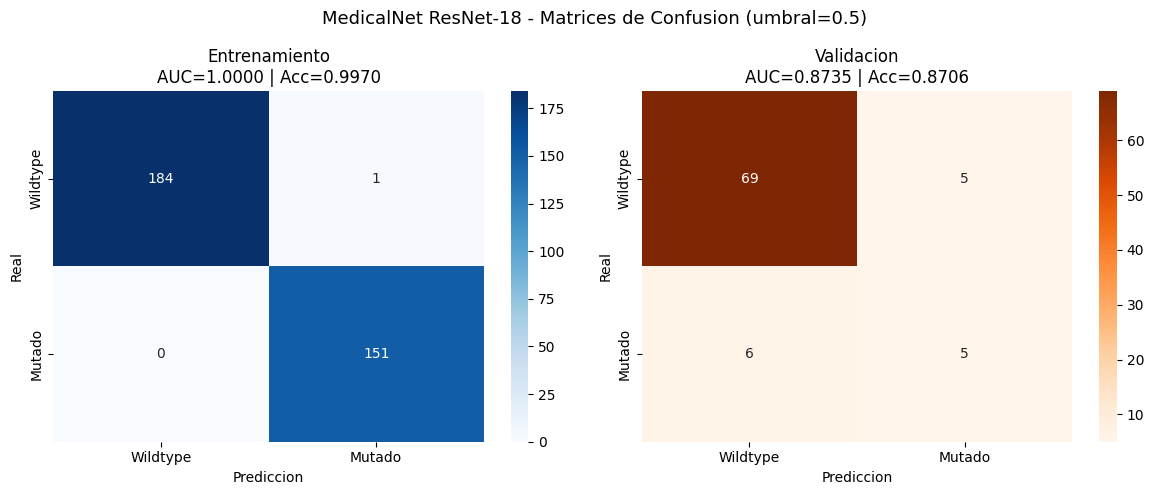

Figura guardada.


In [ ]:
# CELDA 12 - Matrices de confusion entrenamiento y validacion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Entrenamiento ---
probs_tr, labels_tr = [], []
model.eval()
with torch.no_grad():
    for imagenes, etiquetas in loader_train:
        imagenes = imagenes.to(DEVICE)
        salida   = model(imagenes)
        probs_tr.extend(torch.sigmoid(salida).cpu().numpy().flatten())
        labels_tr.extend(etiquetas.numpy().flatten())

preds_tr = (np.array(probs_tr) >= 0.5).astype(int)
cm_tr    = confusion_matrix(labels_tr, preds_tr)
sns.heatmap(cm_tr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Wildtype', 'Mutado'],
            yticklabels=['Wildtype', 'Mutado'])
axes[0].set_title(
    f'Entrenamiento\n'
    f'AUC={roc_auc_score(labels_tr, probs_tr):.4f} | '
    f'Acc={accuracy_score(labels_tr, preds_tr):.4f}'
)
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Prediccion')

# --- Validacion ---
probs_vl, labels_vl = [], []
with torch.no_grad():
    for imagenes, etiquetas in loader_val:
        imagenes = imagenes.to(DEVICE)
        salida   = model(imagenes)
        probs_vl.extend(torch.sigmoid(salida).cpu().numpy().flatten())
        labels_vl.extend(etiquetas.numpy().flatten())

preds_vl = (np.array(probs_vl) >= 0.5).astype(int)
cm_vl    = confusion_matrix(labels_vl, preds_vl)
sns.heatmap(cm_vl, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Wildtype', 'Mutado'],
            yticklabels=['Wildtype', 'Mutado'])
axes[1].set_title(
    f'Validacion\n'
    f'AUC={roc_auc_score(labels_vl, probs_vl):.4f} | '
    f'Acc={accuracy_score(labels_vl, preds_vl):.4f}'
)
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Prediccion')

plt.suptitle('MedicalNet ResNet-18 - Matrices de Confusion (umbral=0.5)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures/medicalnet_confusion_train_val_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

In [ ]:
# CELDA 14 - Evaluar en hold-out con umbral=0.5
import torch
import torch.nn as nn
import numpy as np
import json
from pathlib import Path
from monai.networks.nets import resnet18
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    matthews_corrcoef, recall_score, accuracy_score
)

OUT_DIR   = Path('/content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/dl_clasificador_v2/medicalnet')
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
THRESHOLD = 0.5

# ============================================================
# Reconstruir modelo LIMPIO desde cero y cargar pesos
# ============================================================
backbone = resnet18(spatial_dims=3, n_input_channels=1, num_classes=2)
pesos_orig   = backbone.conv1.weight.data
pesos_nuevos = pesos_orig.repeat(1, 4, 1, 1, 1) / 4.0
backbone.conv1 = nn.Conv3d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
backbone.conv1.weight.data = pesos_nuevos

for param in backbone.conv1.parameters():  param.requires_grad = True
for param in backbone.bn1.parameters():    param.requires_grad = False
for param in backbone.layer1.parameters(): param.requires_grad = False
for param in backbone.layer2.parameters(): param.requires_grad = False
for param in backbone.layer3.parameters(): param.requires_grad = True
for param in backbone.layer4.parameters(): param.requires_grad = True

encoder = nn.Sequential(
    backbone.conv1, backbone.bn1, backbone.act,
    backbone.maxpool,
    backbone.layer1, backbone.layer2,
    backbone.layer3, backbone.layer4,
)

model_eval = nn.Sequential(
    encoder,
    nn.AdaptiveAvgPool3d(1),
    nn.Flatten(),
    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
)

pth_path = OUT_DIR / 'models/medicalnet_best.pth'
model_eval.load_state_dict(torch.load(str(pth_path), map_location=DEVICE))
model_eval.to(DEVICE)
model_eval.eval()
print(f'✅ Modelo cargado desde: {pth_path}')
print(f'   Tamaño: {pth_path.stat().st_size / 1e6:.1f} MB')

# ============================================================
# Evaluar en hold-out con umbral=0.5
# ============================================================
probs_hold, labels_hold = [], []
with torch.no_grad():
    for imagenes, etiquetas in loader_hold:
        imagenes = imagenes.to(DEVICE)
        salida   = model_eval(imagenes)
        probs_hold.extend(torch.sigmoid(salida).cpu().numpy().flatten())
        labels_hold.extend(etiquetas.numpy().flatten())

probs_hold  = np.array(probs_hold)
labels_hold = np.array(labels_hold)
preds_hold  = (probs_hold >= THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(labels_hold, preds_hold).ravel()
spec = tn / (tn + fp + 1e-8)

metricas = {
    'auc'        : float(roc_auc_score(labels_hold, probs_hold)),
    'f1'         : float(f1_score(labels_hold, preds_hold)),
    'accuracy'   : float(accuracy_score(labels_hold, preds_hold)),
    'sensitivity': float(recall_score(labels_hold, preds_hold)),
    'specificity': float(spec),
    'mcc'        : float(matthews_corrcoef(labels_hold, preds_hold)),
    'threshold'  : THRESHOLD,
    'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
}

with open(OUT_DIR / 'results/holdout_metrics.json', 'w') as f:
    json.dump(metricas, f, indent=2)

# Guardar probabilidades para figuras
import pandas as pd
df_probs = pd.DataFrame({
    'sid'       : df_hold['sid'].values,
    'IDH_real'  : ['mutado' if l==1 else 'wildtype' for l in labels_hold],
    'P_mutado'  : probs_hold * 100,
    'P_wildtype': (1 - probs_hold) * 100,
    'prediccion': ['mutado' if p==1 else 'wildtype' for p in preds_hold],
    'correcto'  : [p==l for p,l in zip(preds_hold, labels_hold)],
})
df_probs.to_csv(str(OUT_DIR / 'results/holdout_probs_umbral05.csv'), index=False)

print(f'\nMétricas hold-out - MedicalNet ResNet-18 (umbral={THRESHOLD}):')
print(f'  Casos hold-out  : {len(labels_hold)}')
print(f'  AUC-ROC         : {metricas["auc"]:.4f}')
print(f'  F1-Score        : {metricas["f1"]:.4f}')
print(f'  Sensitivity     : {metricas["sensitivity"]:.4f}')
print(f'  Specificity     : {metricas["specificity"]:.4f}')
print(f'  MCC             : {metricas["mcc"]:.4f}')
print(f'  TP={tp} FP={fp} TN={tn} FN={fn}')
print(f'\n✅ Métricas y probabilidades guardadas.')

✅ Modelo cargado desde: /content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/dl_clasificador_v2/medicalnet/models/medicalnet_best.pth
   Tamaño: 133.3 MB

Métricas hold-out - MedicalNet ResNet-18 (umbral=0.5):
  Casos hold-out  : 106
  AUC-ROC         : 0.9014
  F1-Score        : 0.4364
  Sensitivity     : 0.8571
  Specificity     : 0.6848
  MCC             : 0.3767
  TP=12 FP=29 TN=63 FN=2

✅ Métricas y probabilidades guardadas.


Métricas cargadas:
  AUC=0.9014 | F1=0.4364 | Sens=0.8571 | Spec=0.6848 | MCC=0.3767
  TP=12 FP=29 TN=63 FN=2


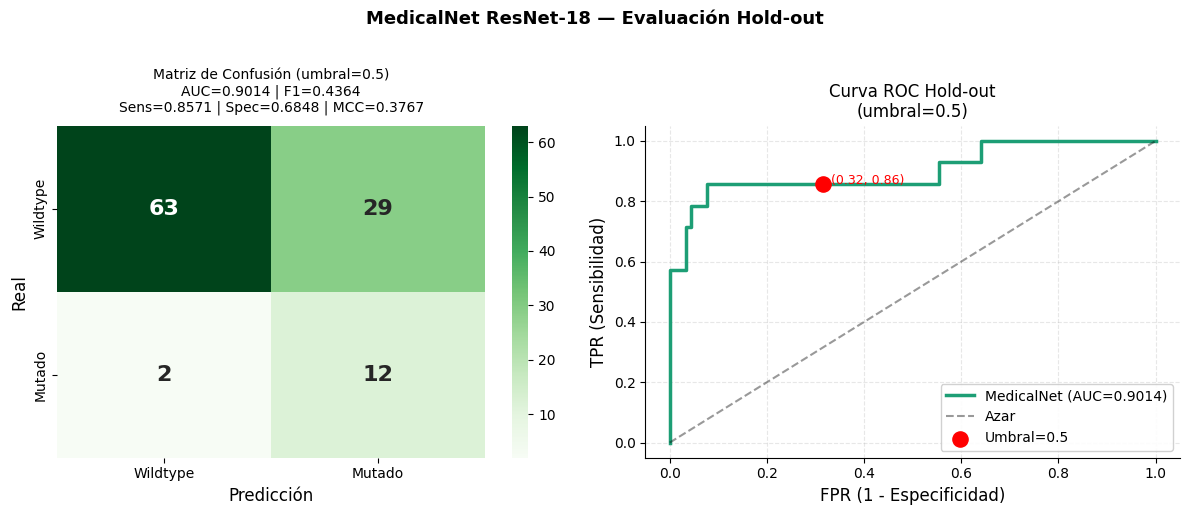

✅ Figura guardada en: medicalnet_holdout_umbral05.png

✅ Pipeline completado.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path
import json

OUT_DIR = Path('/content/drive/MyDrive/GBM_TESIS/SS_PIPELINE/dl_clasificador_v2/medicalnet')
COLOR   = '#1D9E75'

# ============================================================
# LEER MÉTRICAS GUARDADAS POR CELDA 14
# ============================================================
with open(OUT_DIR / 'results/holdout_metrics.json') as f:
    metricas = json.load(f)

TP = metricas['tp']
FP = metricas['fp']
TN = metricas['tn']
FN = metricas['fn']
THRESHOLD = metricas['threshold']
AUC  = metricas['auc']
F1   = metricas['f1']
SENS = metricas['sensitivity']
SPEC = metricas['specificity']
MCC  = metricas['mcc']

# Cargar probabilidades para curva ROC exacta
df_probs    = pd.read_csv(str(OUT_DIR / 'results/holdout_probs_umbral05.csv'))
probs_hold  = df_probs['P_mutado'].values / 100
labels_hold = (df_probs['IDH_real'] == 'mutado').astype(int).values

print(f'Métricas cargadas:')
print(f'  AUC={AUC:.4f} | F1={F1:.4f} | Sens={SENS:.4f} | Spec={SPEC:.4f} | MCC={MCC:.4f}')
print(f'  TP={TP} FP={FP} TN={TN} FN={FN}')

# ============================================================
# FIGURA - Matriz de confusión + Curva ROC juntas
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

# --- Subplot 1: Matriz de confusión ---
cm = np.array([[TN, FP],
               [FN, TP]])

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Wildtype', 'Mutado'],
            yticklabels=['Wildtype', 'Mutado'],
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title(
    f'Matriz de Confusión (umbral={THRESHOLD})\n'
    f'AUC={AUC:.4f} | F1={F1:.4f}\n'
    f'Sens={SENS:.4f} | Spec={SPEC:.4f} | MCC={MCC:.4f}',
    fontsize=10, pad=10
)
axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_xlabel('Predicción', fontsize=12)

# --- Subplot 2: Curva ROC ---
fpr_curve, tpr_curve, _ = roc_curve(labels_hold, probs_hold)
auc_val = roc_auc_score(labels_hold, probs_hold)

fpr_05 = FP / (FP + TN)
tpr_05 = TP / (TP + FN)

axes[1].plot(fpr_curve, tpr_curve, color=COLOR, lw=2.5,
             label=f'MedicalNet (AUC={auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1.5,
             label='Azar')
axes[1].scatter([fpr_05], [tpr_05], color='red', s=120,
                zorder=5, label=f'Umbral={THRESHOLD}')
axes[1].annotate(f'  ({fpr_05:.2f}, {tpr_05:.2f})',
                 xy=(fpr_05, tpr_05), fontsize=9, color='red')
axes[1].set_xlabel('FPR (1 - Especificidad)', fontsize=12)
axes[1].set_ylabel('TPR (Sensibilidad)', fontsize=12)
axes[1].set_title('Curva ROC Hold-out\n'
                  f'(umbral={THRESHOLD})', fontsize=12)
axes[1].legend(fontsize=10, framealpha=0.9)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('MedicalNet ResNet-18 — Evaluación Hold-out',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figures/medicalnet_holdout_umbral05.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Figura guardada en: medicalnet_holdout_umbral05.png')
print('\n✅ Pipeline completado.')